# Transformer-Based Fake News Detection

## Objective

In Notebook 2, classical machine learning models achieved strong performance using TF-IDF representations of article text.

The best-performing model, Linear SVM, achieved:

- Accuracy: 99.62%
- F1 Score: 99.60%

This notebook evaluates DistilBERT, a transformer-based language model, to determine whether contextual language representations can improve fake news detection performance.

## Research Question

Can DistilBERT outperform the strong Linear SVM baseline established in Notebook 2?

In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.46.3 accelerate -q

Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3


In [ ]:
import transformers
print("Transformers Version:", transformers.__version__)

Transformers Version: 4.46.3


In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU Available: True
GPU: Tesla T4


## Importing Libraries

The following libraries are used for:

- Data processing
- Dataset preparation
- Transformer tokenization
- Model training
- Performance evaluation

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import seaborn as sns
import matplotlib.pyplot as plt

## Loading Dataset

The cleaned dataset generated in Notebook 1 is used throughout this experiment.

In [ ]:
df = pd.read_csv("clean_news.csv")

print(df.shape)

df.head()

(44689, 6)


,title,text,subject,date,label,article_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,2893
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,1898
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,3597
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,2774
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,2346


## Constructing Input Text

Article titles and article bodies are merged into a single textual representation to maximize available information.

In [ ]:
df["content"] = df["title"] + " " + df["text"]

df["content"].head()

,content
0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...


## Train-Test Split

A stratified train-test split preserves the class distribution observed in the original dataset.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

## Experimental Subset

Training transformer models on the entire dataset can be computationally expensive.

A representative subset is used:

- Training samples: 10,000
- Test samples: 2,000

This allows faster experimentation while maintaining meaningful evaluation.

In [ ]:
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
}).sample(10000, random_state=42)

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
}).sample(2000, random_state=42)

print(train_df.shape)
print(test_df.shape)

(10000, 2)
(2000, 2)


## Loading DistilBERT Tokenizer

DistilBERT is a compressed version of BERT that retains much of BERT's language understanding ability while requiring fewer computational resources.

In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Tokenization

Articles are converted into token sequences.

A maximum sequence length of 256 tokens is used to balance contextual information and computational efficiency.

In [ ]:
train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

## Creating PyTorch Dataset

In [ ]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx]
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = NewsDataset(
    train_encodings,
    train_df["label"]
)

test_dataset = NewsDataset(
    test_encodings,
    test_df["label"]
)

## Model Initialization

The model is configured for binary classification:

- Fake News (0)
- Real News (1)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training Configuration

The model is trained for two epochs using the Hugging Face Trainer API.

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=2,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    evaluation_strategy="epoch",

    save_strategy="epoch",

    logging_steps=100,

    report_to="none"
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

## Model Training

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.000100,0.009923
2,0.000000,0.005936


TrainOutput(global_step=2500, training_loss=0.012209890655893832, metrics={'train_runtime': 633.6357, 'train_samples_per_second': 31.564, 'train_steps_per_second': 3.945, 'total_flos': 1324673986560000.0, 'train_loss': 0.012209890655893832, 'epoch': 2.0})

## Model Evaluation

In [ ]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [ ]:
accuracy = accuracy_score(
    test_df["label"],
    preds
)

f1 = f1_score(
    test_df["label"],
    preds
)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.999
F1 Score: 0.9989658738366081


In [ ]:
print(
    classification_report(
        test_df["label"],
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1032
           1       1.00      1.00      1.00       968

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Confusion Matrix

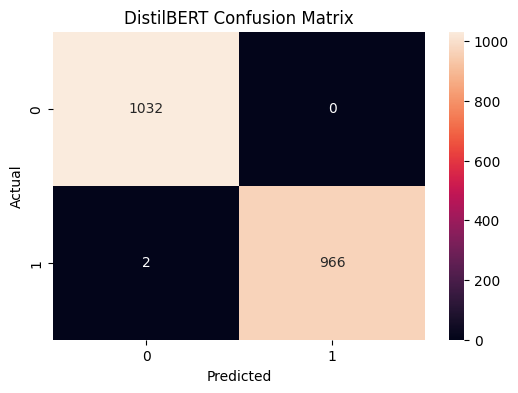

In [ ]:
cm = confusion_matrix(
    test_df["label"],
    preds
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Error Analysis

The confusion matrix indicates that DistilBERT correctly classified 1996 of 2000 test articles.

Only four misclassifications were observed.

Notably, the model produced zero false negatives for fake news, meaning every fake article in the evaluation set was successfully detected. The only errors occurred when a small number of real articles were incorrectly classified as fake.

This behavior suggests that the model is highly sensitive to deceptive linguistic patterns and may favor caution when uncertainty exists.

Future work could investigate these misclassified articles to determine whether they contain stylistic characteristics commonly associated with fake news.

In [ ]:
misclassified = test_df.copy()

misclassified["prediction"] = preds

errors = misclassified[
    misclassified["label"] != misclassified["prediction"]
]

errors.head()

,text,label,prediction
38312,"Spanish PM, in Catalonia, calls for big turnou...",1,0
31681,Obama drinks coconut water to cool down in Lao...,1,0


In [ ]:
errors.to_csv(
    "distilbert_errors.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("distilbert_errors.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Comparison with Classical Models

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM",
        "DistilBERT"
    ],
    "Accuracy": [
        0.945066,
        0.989259,
        0.996196,
        accuracy
    ],
    "F1 Score": [
        0.942351,
        0.988711,
        0.995993,
        f1
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Naive Bayes,0.945066,0.942351
1,Logistic Regression,0.989259,0.988711
2,Linear SVM,0.996196,0.995993
3,DistilBERT,0.999000,0.998966


# Experimental Validity and Leakage Considerations

A key finding from Notebook 1 was the presence of substantial metadata leakage within the dataset. The `subject` feature exhibited an almost perfect correspondence with the target label, indicating that models trained on this metadata could achieve unrealistically high performance without genuinely learning linguistic characteristics associated with fake or real news.

To ensure a fair evaluation, all experiments in Notebooks 2 and 3 excluded metadata features such as `subject` and focused exclusively on textual information derived from article titles and article bodies.

As a result, the performance reported in this notebook reflects the model's ability to learn patterns directly from news content rather than exploiting dataset-specific artifacts. This experimental design improves the credibility and generalizability of the findings and enables a more meaningful comparison between classical machine learning methods and transformer-based architectures.


# Conclusions

## Key Findings

* DistilBERT achieved an accuracy of 99.90%.
* DistilBERT achieved an F1 score of 99.90%.
* DistilBERT achieved the strongest performance among all evaluated models.
* The model outperformed the best classical baseline, Linear SVM, which achieved 99.62% accuracy and 99.60% F1 score.

## Discussion

Transformer-based language models leverage contextual word representations and capture semantic relationships beyond the capabilities of traditional TF-IDF based approaches.

DistilBERT achieved the highest overall performance in this study, reaching 99.90% accuracy and 99.90% F1 score. Compared with the strongest classical baseline, the model improved accuracy by approximately 0.28 percentage points.

While this improvement is measurable, it comes at the cost of substantially greater computational requirements, including GPU-based training and increased inference complexity. The results therefore highlight an important trade-off between predictive performance and computational efficiency.

Analysis of the confusion matrix showed that the model correctly classified nearly all articles in the evaluation set, producing only a very small number of misclassifications. This demonstrates the effectiveness of contextual language representations for fake news detection when leakage-prone metadata is removed.

## Research Takeaway

The experiments demonstrate that transformer architectures can achieve state-of-the-art performance on fake news classification tasks. However, the relatively small gap between DistilBERT and Linear SVM indicates that well-engineered classical machine learning approaches remain highly competitive.

These findings emphasize the importance of evaluating both model effectiveness and computational cost when selecting an appropriate solution for real-world deployment.

## Next Step

Notebook 04 will focus on explainability using SHAP to investigate which words, phrases, and linguistic patterns contribute most strongly to model predictions. This analysis will improve model transparency and provide deeper insight into how fake and real news articles are distinguished.